# Урок 2.2. Критерии разбиения: MSE, Джини, энтропия

**Интерактивная версия:** `lessons/lesson_2_2/web/index.html`

1. Меры неоднородности и их графики.
2. Выигрыш разбиения по разным критериям на восьми точках.
3. Джини = 2 × дисперсия меток: регрессионное дерево на 0/1 совпадает с деревом классификации.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from gbcourse import datasets, RegressionTree
from gbcourse.plotting import use_course_style

use_course_style()

gini = lambda p: 2 * p * (1 - p)
entropy = lambda p: 0.0 if p <= 0 or p >= 1 else -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
miscl = lambda p: min(p, 1 - p)

## 1. Меры неоднородности

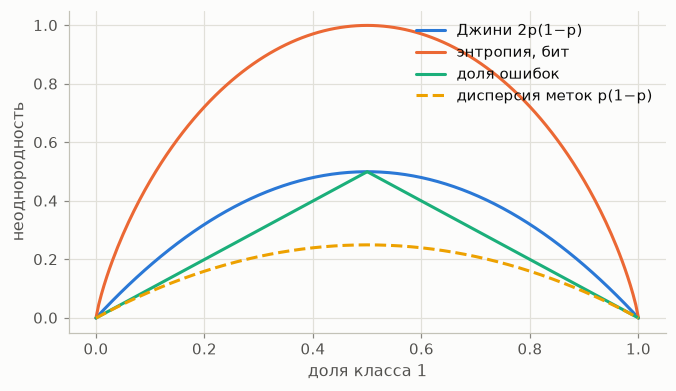

In [2]:
ps = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(ps, [gini(p) for p in ps], label="Джини 2p(1−p)")
ax.plot(ps, [entropy(p) for p in ps], label="энтропия, бит")
ax.plot(ps, [miscl(p) for p in ps], label="доля ошибок")
ax.plot(ps, ps * (1 - ps), ls="--", label="дисперсия меток p(1−p)")
ax.set(xlabel="доля класса 1", ylabel="неоднородность")
ax.legend()
plt.show()

## 2. Выигрыш разбиения на восьми точках

In [3]:
X, y = datasets.toy_classification()
x = X[:, 0]
rows = []
for t in np.arange(1.5, 8, 1.0):
    L, R = y[x <= t], y[x > t]
    wl, wr = len(L) / len(y), len(R) / len(y)
    row = {"порог": t}
    for name, f in [("Джини", gini), ("энтропия", entropy), ("доля ошибок", miscl)]:
        row[name] = f(y.mean()) - wl * f(L.mean()) - wr * f(R.mean())
    rows.append(row)
pd.DataFrame(rows).round(4)

,порог,Джини,энтропия,доля ошибок
0,1.5,0.0714,0.1379,0.125
1,2.5,0.1667,0.3113,0.250
2,3.5,0.3000,0.5488,0.375
3,4.5,0.1250,0.1887,0.250
4,5.5,0.3000,0.5488,0.375
5,6.5,0.1667,0.3113,0.250
6,7.5,0.0714,0.1379,0.125


Джини и энтропия оба выбирают порог 3.5 (у 5.5 столько же). Доля ошибок даёт одинаковый выигрыш
многим порогам — она «грубее».

## 3. Джини и дисперсия: одно и то же дерево

In [4]:
Xc, yc = datasets.classification_2d(kind="moons", n=300, noise=0.3, seed=7)
reg = RegressionTree(max_depth=4).fit(Xc, -yc)  # регрессия на метках 0/1
clf = DecisionTreeClassifier(max_depth=4, criterion="gini").fit(Xc, yc)
p_reg = reg.predict(Xc)
p_clf = clf.predict_proba(Xc)[:, 1]
print("максимальная разница вероятностей:", np.abs(p_reg - p_clf).max())
print("одинаковые группы листьев:", len(set(zip(reg.apply(Xc), clf.apply(Xc)))) == reg.n_leaves)

максимальная разница вероятностей: 0.0
одинаковые группы листьев: True


Регрессионное дерево на 0/1 и дерево классификации с Джини совпадают (с точностью до порядка
перебора признаков при ничьих). Поэтому в курсе классификационные деревья строятся тем же кодом,
что и регрессионные, — как и в градиентном бустинге.

## Упражнения

1. Найдите пример разбиения, при котором доля ошибок не меняется, а Джини уменьшается.
2. Постройте на данных `moons` деревья с критериями `gini` и `entropy` (sklearn) глубины 1…8 и сравните точность на тесте.
3. Докажите, что взвешенная сумма Джини в детях не больше Джини родителя (подсказка: вогнутость $p(1-p)$).

Решения: `python lessons/lesson_2_2/exercises/solutions.py`.